In [1]:
import numpy as np
import cv2
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

path = Path("../MyDataset/Faces/Faces/Faces")
images = []
for p in sorted(path.iterdir()):
    img_aux = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    if img_aux is None:
        continue
    img_res = cv2.resize(img_aux, (100, 100))
    images.append(img_res.flatten())

Xd = np.array(images).astype(np.float32)
print(Xd.shape)


(2592, 10000)


## In urmatoarea parte calculez fata medie

(10000,)


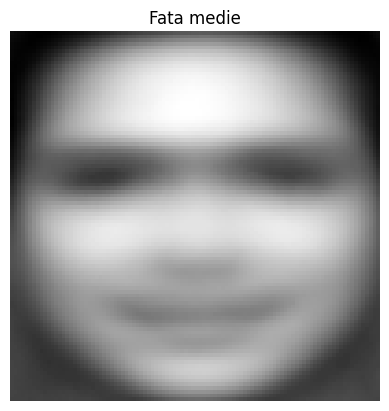

In [2]:
psi = np.mean(Xd, axis=0)
print(psi.shape)
psi_img = psi.reshape(100, 100)
plt.imshow(psi_img, cmap='gray')
plt.title('Fata medie')
plt.axis('off')
plt.show()

### Noua poza medie

In [3]:
A = Xd - psi
C = np.dot(A,np.transpose(A))
vect_vals, vect_props = np.linalg.eigh(C)
idx = np.argsort(vect_vals)[::-1]
vect_vals = vect_vals[idx]
vect_props = vect_props[:,idx]
print(C.shape)
print(vect_vals.shape) # cat de imp e fiecare directie, desc
print(vect_props.shape) # vect cu toate directiile, desc
#print(vect_vals)
#print(vect_props)



(2592, 2592)
(2592,)
(2592, 2592)


In [4]:
#eu am A pe randuri, nu coloana , este vect transpus
K = 150
new_V_props = vect_props[:,:K]
print(new_V_props.shape)
u = np.dot(np.transpose(A),new_V_props)
u = u / np.linalg.norm(u, axis=0)
print(u.shape)
w = np.dot(A,u)
print(w.shape)
print(w)


(2592, 150)
(10000, 150)
(2592, 150)
[[ -615.66864  -3176.7087     160.18582  ...   -41.534046   -21.496162
     56.036156]
 [ -385.82297   -229.48819   -627.99023  ...  -112.062225   -25.207788
    -45.490273]
 [ -574.72485    409.71756  -1353.2731   ...  -223.42488   -102.50304
    124.054   ]
 ...
 [ 3029.384    -1353.0278      80.25806  ...    92.80454    110.64363
    -28.648422]
 [  -13.897211 -1515.569     -171.49948  ...   123.77505   -182.6886
    217.07573 ]
 [-1664.3599    -266.48846   1245.99     ...  -126.24792    147.51915
    -31.687252]]


In [5]:
df = pd.read_csv('../MyDataset/Faces/Dataset.csv')
df = df.sort_values(by='id')
arr = df['label'].to_numpy()
arr

array(['Akshay Kumar', 'Akshay Kumar', 'Akshay Kumar', ..., 'Zac Efron',
       'Zac Efron', 'Zac Efron'], shape=(2592,), dtype=object)

### Partea de SVM , antrenare

{'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': True, 'random_state': 10, 'shrinking': True, 'tol': 0.001, 'verbose': False}
Accuracy: 0.55
Precision: 0.66
Recall: 0.53
roc_auc : 0.94


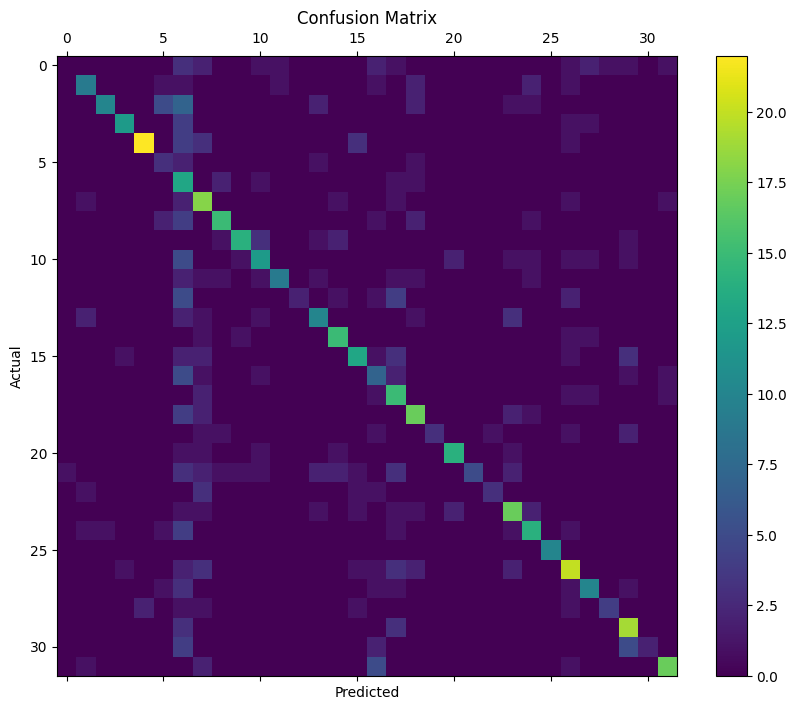

In [6]:
from sklearn.metrics import precision_score, accuracy_score, confusion_matrix, recall_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

le = LabelEncoder()
arr_encoded = le.fit_transform(arr)
scaler = StandardScaler()
w_scaled = scaler.fit_transform(w)

X_train, X_test, y_train, y_test = train_test_split(w_scaled, arr_encoded, test_size=0.25, random_state=10)
svm = SVC(random_state=10, probability=True)
svm.fit(X_train, y_train)
probabilities = svm.predict_proba(X_test)
y_pred = svm.predict(X_test)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
roc = roc_auc_score(y_test, probabilities, multi_class='ovr', average='macro')

print(svm.get_params())
print(f"Accuracy: {acc:.2f}")
print(f'Precision: {prec:.2f}')
print(f'Recall: {recall:.2f}')
print(f'roc_auc : {roc:.2f}')

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
plt.matshow(conf_matrix, fignum=1)
plt.colorbar()
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Din punct de vedere probabilistic, 95% din cazuri isi da seama cine e persoana, dar cum SVM nu se ia dupa probabilitati, ci dupa distanta euclidiana, acuratetea este de aprox 50%.

In [7]:
files = sorted(path.iterdir())
print(files[:5])
print(arr[:5])

[WindowsPath('../MyDataset/Faces/Faces/Faces/Akshay Kumar_0.jpg'), WindowsPath('../MyDataset/Faces/Faces/Faces/Akshay Kumar_1.jpg'), WindowsPath('../MyDataset/Faces/Faces/Faces/Akshay Kumar_10.jpg'), WindowsPath('../MyDataset/Faces/Faces/Faces/Akshay Kumar_11.jpg'), WindowsPath('../MyDataset/Faces/Faces/Faces/Akshay Kumar_12.jpg')]
['Akshay Kumar' 'Akshay Kumar' 'Akshay Kumar' 'Akshay Kumar'
 'Akshay Kumar']


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params: {'C': 10, 'gamma': 0.005, 'kernel': 'rbf'}
Accuracy: 0.59
Precision: 0.63
Recall: 0.58
ROC AUC: 0.95


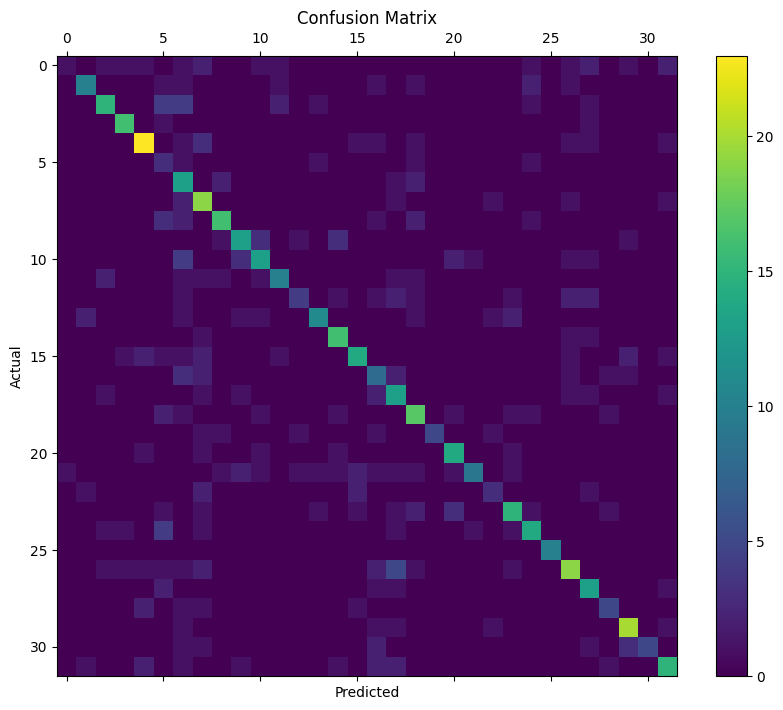

In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [1, 5, 10,12,14,15, 50, 100],
    'gamma': [0.001, 0.005,0.007,0.009, 0.01, 0.05],
    'kernel': ['rbf']
}

grid = GridSearchCV(
    estimator = SVC(probability=True),
    param_grid = param_grid,
    n_jobs= - 1,
    cv=5,
    refit = True,
    verbose = 3)
grid.fit(X_train, y_train)
print(f"Best params: {grid.best_params_}")
best_svm = grid.best_estimator_
probabilities = best_svm.predict_proba(X_test)
y_pred = best_svm.predict(X_test)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
roc = roc_auc_score(y_test, probabilities, multi_class='ovr', average='macro')

print(f"Accuracy: {acc:.2f}")
print(f'Precision: {prec:.2f}')
print(f'Recall: {recall:.2f}')
print(f'ROC AUC: {roc:.2f}')
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
plt.matshow(conf_matrix, fignum=1)
plt.colorbar()
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## KNN

Accuracy: 0.39
Precision: 0.49
Recall: 0.38
roc_auc : 0.81


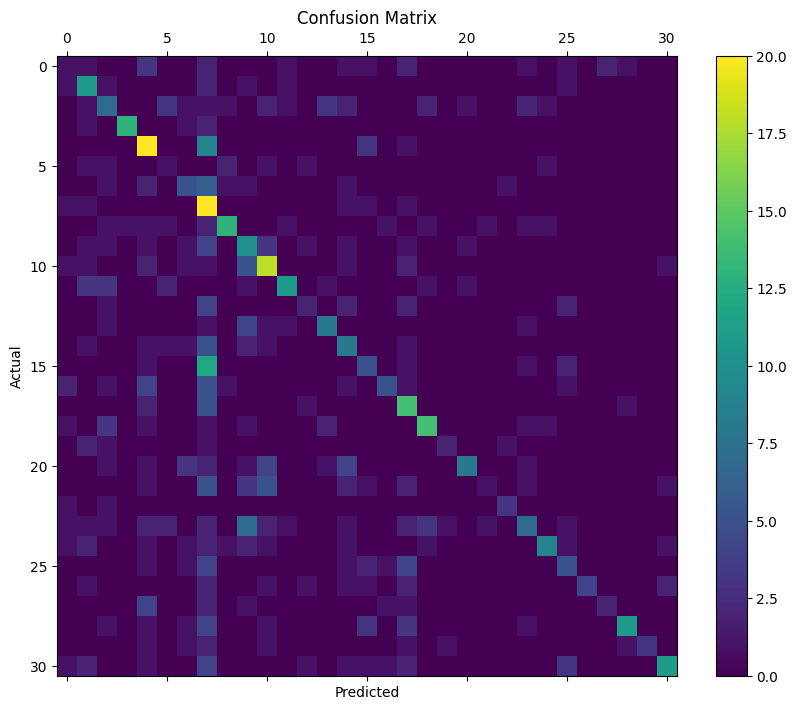

In [68]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
probabilities_knn = knn.predict_proba(X_test)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro',zero_division=0)
recall = recall_score(y_test, y_pred, average='macro',zero_division=0)
roc = roc_auc_score(y_test, probabilities_knn, multi_class='ovr', average='macro')

print(f"Accuracy: {acc:.2f}")
print(f'Precision: {prec:.2f}')
print(f'Recall: {recall:.2f}')
print(f'roc_auc : {roc:.2f}')

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
plt.matshow(conf_matrix, fignum=1)
plt.colorbar()
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Random Forest

Accuracy: 0.44
Precision: 0.49
Recall: 0.43
roc_auc : 0.88


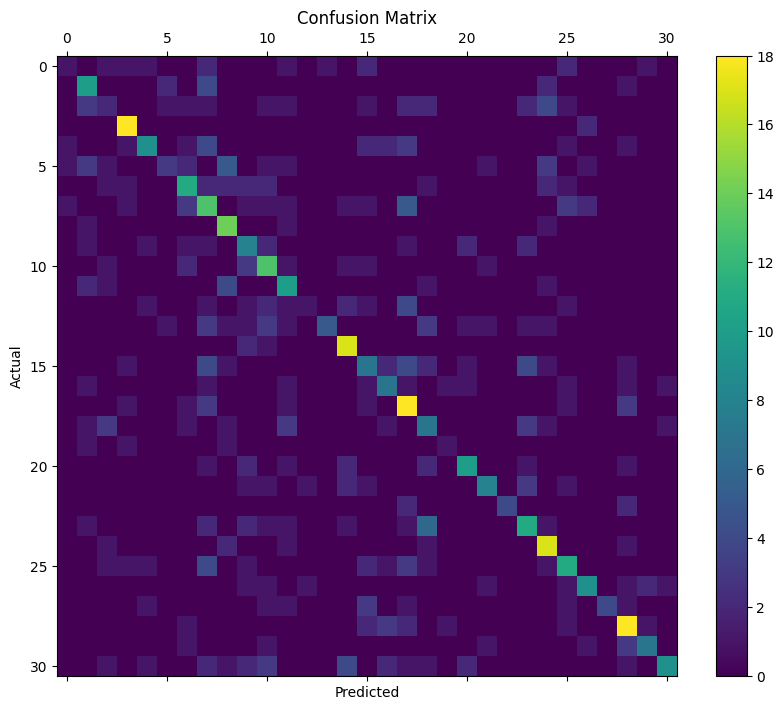

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
probabilities_rf = rf.predict_proba(X_test)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
roc = roc_auc_score(y_test, probabilities_rf, multi_class='ovr', average='macro')

print(f"Accuracy: {acc:.2f}")
print(f'Precision: {prec:.2f}')
print(f'Recall: {recall:.2f}')
print(f'roc_auc : {roc:.2f}')

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
plt.matshow(conf_matrix, fignum=1)
plt.colorbar()
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## XGBoost

Accuracy: 0.42
Precision: 0.43
Recall: 0.42
ROC AUC: 0.91


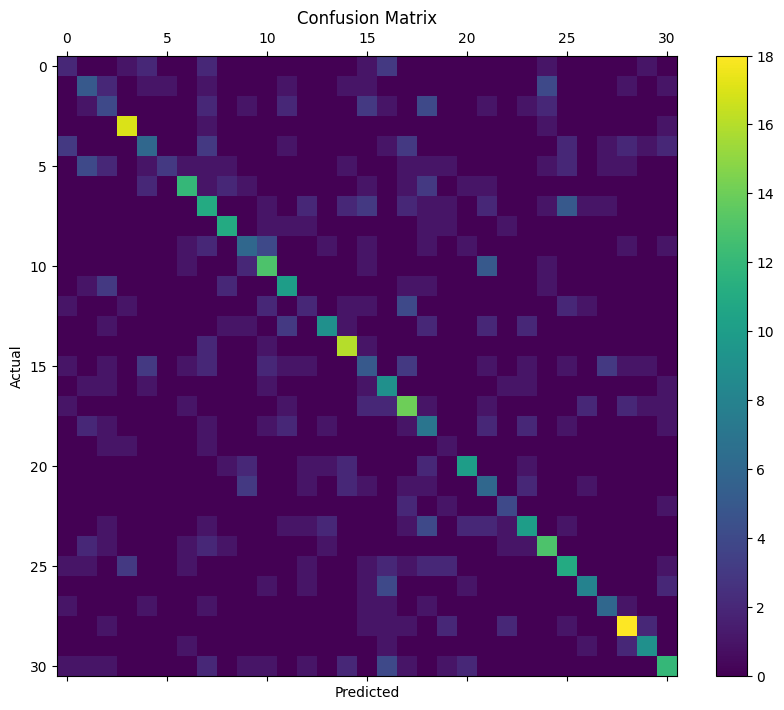

In [44]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
probabilities_xgb = xgb.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
roc = roc_auc_score(y_test, probabilities_xgb, multi_class='ovr', average='macro')

print(f"Accuracy: {acc:.2f}")
print(f'Precision: {prec:.2f}')
print(f'Recall: {recall:.2f}')
print(f'ROC AUC: {roc:.2f}')

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
plt.matshow(conf_matrix, fignum=1)
plt.colorbar()
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()